## **Agentic AI**
 1. A ChatBot just talks to you.
 2. A ReAct Agent thinks about your problem, uses tools to find the answer, and then talks to you.

# **ReAct**
 A normal chatbot just guesses the answer based on its training. A ReAct Agent works in a loop of three steps:
 1. Thought (Reasoning): The AI thinks out loud about what it needs to do.
 2. Action (Acting): The AI uses a tool (like a search engine, a database, or a math calculator).
 3. Observation: The AI looks at the result of the tool and decides what to do next.

## **Simple Example**
"What is the current weather in London, and should I bring an umbrella?"

A normal chatbot might guess or give you outdated weather. A ReAct Agent will do this:

 1. Thought 1: "I need to know the current weather in London. I should use my weather tool."
 2. Action 1: Calls the Weather API for "London".
 3. Observation 1: The API says: "Rainy, 60°F, 90% chance of rain."
 4. Thought 2: "The weather API says there is a 90% chance of rain. I should tell the user to bring an umbrella."

Final Answer: "It is rainy in London right now, so yes, you should definitely bring an umbrella!"

In [1]:
from typing import TypedDict
from typing_extensions import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import HumanMessage
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
import warnings
warnings.filterwarnings("ignore")

load_dotenv()

True

In [2]:
## create the state
class State(TypedDict):
    messages: Annotated[list, add_messages] ## you need add messages into the list type with the help of add_messages


## llm object
llm_gai = ChatGoogleGenerativeAI(
            model = "gemini-3.5-flash-lite",
            max_tokens = 346,
)

In [3]:
## initialize
tool = TavilySearch(max_results=2)

tool.invoke("What is AI agent")

{'query': 'What is AI agent',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aws.amazon.com/what-is/ai-agents',
   'title': 'What are AI Agents?',
   'content': 'An artificial intelligence (AI) agent is a software program that can interact with its environment, collect data, and use that data to perform self-directed tasks that meet predetermined goals. Humans set goals, but an AI agent independently chooses the best actions it needs to perform to achieve those goals. For example, consider a contact center AI agent that wants to resolve customer queries. The agent will automatically ask the customer different questions, look up information in internal [...] For example, in autonomous vehicle fleets, each vehicle acts as an independent agent but collaborates with others to avoid traffic congestion and prevent collisions, leading to smoother traffic flow.\n\n## What are the challenges of using AI agents?\n\nAI agents are helpful software techn

In [ ]:
## simple tool
def greeting_tool(greet: str):
    """
    Greet them saying - Namaste🙏, Mero naam AI ho!

    Args:
        greet (str): input says - Hello or Hi.

    Returen:
        str: Output with Nepali way of greetings.
    """
    return str(greet)

## math tool


## list of tool
tools = [tool, greeting_tool]


## bind the llm with list of tools
llm_tools = llm_gai.bind_tools(tools)

In [5]:
from langchain.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

## define tools
def tool_calling_llm(state: State):
    return {"messages": [llm_tools.invoke(state['messages'])]}

## Node graph 
builder = StateGraph(State)
builder.add_node("Saroj_tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## edge graph
builder.add_edge(START, "Saroj_tool_calling_llm")
builder.add_conditional_edges(
    "Saroj_tool_calling_llm",
    # if the latest message (result) from the assistance is a tool call -> tool_condition routes to tool
    # if the latest message (result) from the assistance is not a tool call -> tool_condition routes to END
    tools_condition
 )

builder.add_edge("tools", "Saroj_tool_calling_llm")

## compile the entire graph
Bot_graph = builder.compile()


In [6]:
response = Bot_graph.invoke({"messages": ["Hi, What is the AI news for today?"]})

response['messages'][-1].text

"Namaste🙏, Mero naam AI ho!\n\nHere are some of the key trends and developments making waves in the world of Artificial Intelligence:\n\n1. **AI Safety & Pacing Debates:** Major industry discussions are heavily focused on scaling, pacing, and safety frameworks. Leaders across top AI labs have been debating the future velocity of AI development, balancing rapid frontier model innovation with rigorous safety considerations.\n2. **Real-World Healthcare Applications:** Open-source AI models continue to drive major breakthroughs in medicine. For instance, advanced open-source architectures (like NVIDIA's MONAI framework used at institutions like the Children's Hospital of Philadelphia) are empowering doctors to generate highly accurate 3D cardiac and organ models from medical scans, significantly improving pediatric care.\n3. **Multimodal Capabilities & Personal Agents:** Tech giants are continually rolling out updates centered around omni-directional audio-visual capabilities, deeper memor

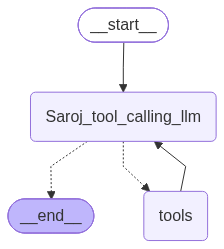

In [7]:
Bot_graph